In [31]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from matplotlib import pyplot
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt

In [32]:
# random seed for always same results
tf.random.set_seed(678)
print(tf.__version__)

2.20.0


### model

In [33]:
model = Sequential()
# first dense layer
model.add(Dense(units=2, input_shape=(2,), activation='sigmoid'))
#model.add(Dense(units=4, activation='sigmoid'))
#model.add(Dense(units=4, activation='sigmoid'))
#model.add(Dense(units=2, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))
# loss function and optimization

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(tf.keras.optimizers.SGD(learning_rate=0.2), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

### Simple Data Xy

In [35]:
X = np.array([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = np.array([0.,1.,1.,1.])

In [36]:
# generate 2d classification dataset
# 복잡하게 ?
X, y = make_moons(n_samples=50, noise=.06)

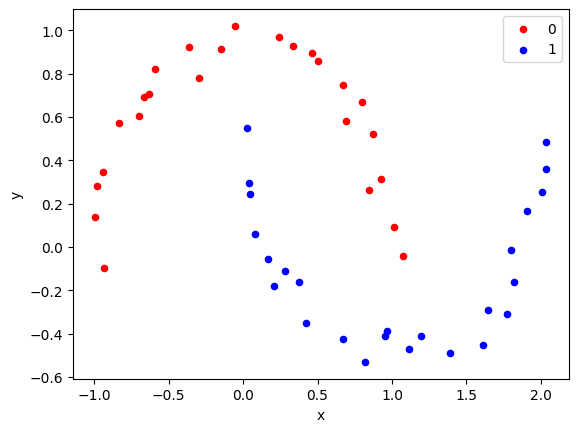

In [37]:
# scatter plot, dots colored by class value
df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
colors = {0:'red', 1:'blue', 2:'green'}
fig, ax = pyplot.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
pyplot.show()

### model.fit

In [38]:
class callback(tf.keras.callbacks.Callback):
    SHOW_NUMBER = 2000
    counter = 0
    epoch = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch = epoch

    def on_train_batch_end(self, batch, logs=None):
        if self.counter == self.SHOW_NUMBER or self.epoch == 1:
            print('Epoch: ' + str(self.epoch) + ' loss: ' + str(logs['loss']))
            if self.epoch > 1:
                self.counter = 0
        self.counter += 1

In [39]:
batchNum = 100
epochNum = 50000

In [40]:
history = model.fit(X, y, batch_size=batchNum, epochs=epochNum, callbacks=[callback()], verbose=0)

Epoch: 1 loss: 0.7222616672515869
Epoch: 2000 loss: 0.3032281994819641
Epoch: 4000 loss: 0.30110225081443787
Epoch: 6000 loss: 0.29989510774612427
Epoch: 8000 loss: 0.29909244179725647
Epoch: 10000 loss: 0.2984645664691925
Epoch: 12000 loss: 0.29785895347595215
Epoch: 14000 loss: 0.29708436131477356
Epoch: 16000 loss: 0.2958092987537384
Epoch: 18000 loss: 0.2937065362930298
Epoch: 20000 loss: 0.29111871123313904
Epoch: 22000 loss: 0.28890034556388855
Epoch: 24000 loss: 0.2873867452144623
Epoch: 26000 loss: 0.28643712401390076
Epoch: 28000 loss: 0.2858436107635498
Epoch: 30000 loss: 0.2854611277580261
Epoch: 32000 loss: 0.2852032482624054
Epoch: 34000 loss: 0.2850204408168793
Epoch: 36000 loss: 0.2848837971687317
Epoch: 38000 loss: 0.2847761809825897
Epoch: 40000 loss: 0.28468695282936096
Epoch: 42000 loss: 0.28460901975631714
Epoch: 44000 loss: 0.28453752398490906
Epoch: 46000 loss: 0.2844686508178711
Epoch: 48000 loss: 0.28439903259277344


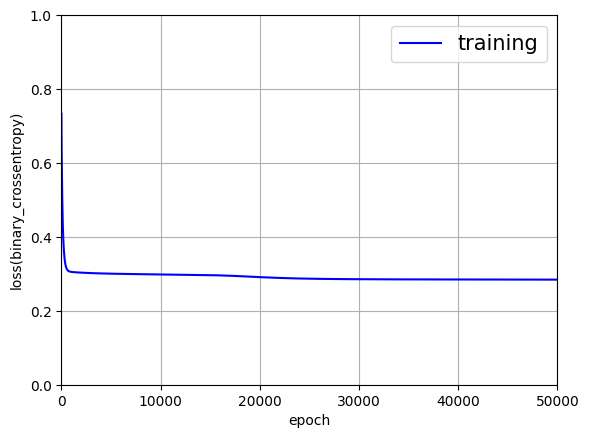

In [41]:
plt.plot(pd.DataFrame(history.history)[['loss']],'b', label='training')
# plt.figure(figsize=(5,5), dpi=10000, facecolor='w', edgecolor='k')
plt.xlabel("epoch")
plt.ylabel("loss(binary_crossentropy)")  # "Loss(MAE)"  logcosh
plt.rcParams['figure.figsize'] = [15, 6]
font = {'weight' : 'normal', 'size' : 15}
plt.rc('font', **font)
# plt.title('node #:' + str(nodeNum)+' / layer #:'+str(layerNum))
plt.grid(True)
plt.legend()
plt.xlim(-1, epochNum+1)
plt.ylim(0, 1)
# plt.savefig(MODEL_SAVE_FOLDER_PATH+'_learningcurve_'+case_name+'.png', dpi=300)
plt.show()

In [42]:
print("first layer weights: ",model.layers[0].get_weights()[0])
print("first layer bias: ",model.layers[0].get_weights()[1])
print("second layer weights: ",model.layers[1].get_weights()[0])
print("second layer bias: ",model.layers[1].get_weights()[1])

first layer weights:  [[ 1.3683159 -1.6779993]
 [-4.7961884  5.6383295]]
first layer bias:  [-2.9396012 -4.5921454]
second layer weights:  [[ 9.142863]
 [-9.360426]]
second layer bias:  [-0.16151264]


In [43]:
py = model.predict(X)
lpy = tf.cast(py > 0.5, dtype=tf.float32)
for i in range(0, len(py), 5):
  print(y[i], py[i], lpy.numpy()[i])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1 [0.9991235] [1.]
1 [0.8868462] [1.]
1 [0.97072583] [1.]
1 [0.9972306] [1.]
0 [0.00712806] [0.]
0 [0.0006072] [0.]
1 [0.75490075] [1.]
0 [0.02994111] [0.]
0 [0.00086587] [0.]
1 [0.99447376] [1.]


In [44]:
model.weights

[<Variable path=sequential_3/dense_10/kernel, shape=(2, 2), dtype=float32, value=[[ 1.3683159 -1.6779993]
  [-4.7961884  5.6383295]]>,
 <Variable path=sequential_3/dense_10/bias, shape=(2,), dtype=float32, value=[-2.9396012 -4.5921454]>,
 <Variable path=sequential_3/dense_11/kernel, shape=(2, 1), dtype=float32, value=[[ 9.142863]
  [-9.360426]]>,
 <Variable path=sequential_3/dense_11/bias, shape=(1,), dtype=float32, value=[-0.16151264]>]

In [45]:
lpy = np.array(lpy)

In [47]:
lpy = np.reshape(lpy,(50,))
print(y.shape, lpy.shape)

(50,) (50,)


In [ ]:
colors = {0:'red', 1:'blue'}

df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
grouped = df.groupby('label')
fig, ax = pyplot.subplots()
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
pyplot.show()

df = DataFrame(dict(x=X[:,0], y=X[:,1], label=lpy))
grouped = df.groupby('label')
fig, ax = pyplot.subplots()
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
pyplot.show()

# generate blobs of points with a Gaussian distribution.

In [ ]:
# generate 2d classification dataset
X, y = make_blobs(n_samples=100, centers=2, n_features=2)

In [ ]:
# scatter plot, dots colored by class value
df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
colors = {0:'red', 1:'blue', 2:'green'}
fig, ax = pyplot.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
pyplot.show()

In [ ]:
np.set_printoptions(linewidth=220, precision=2)
print(X.T)

In [ ]:
print(y)

In [ ]:
# generate 2d classification dataset
X, y = make_moons(n_samples=100, noise=.16)

In [ ]:
# scatter plot, dots colored by class value
df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
colors = {0:'red', 1:'blue', 2:'green'}
fig, ax = pyplot.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
pyplot.show()

In [ ]:
np.set_printoptions(linewidth=220, precision=2)
print(X.T)

In [ ]:
print(y)

# ML ex2data1

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

##### ex2data1, data2
https://drive.google.com/file/d/176uBDnnuoyLQuqR2oeWC3BkBL023puwQ/view?usp=sharing

https://drive.google.com/file/d/1EJf9oTrbjW-jE6oJyrfA1ukuQU0nyxbw/view?usp=sharing

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DL2022/notebook/data/ex2data1.txt', sep=',', names=['Exam 1 Score', 'Exam 2 Score', 'Result'], header=None)

In [ ]:
data

In [ ]:
import seaborn as sns

In [ ]:
g =sns.scatterplot(x = 'Exam 1 Score', y = 'Exam 2 Score', hue = 'Result', data = data, style = 'Result')